# Effect of tomogram preprocessing on membrane thickness measurements

This tutorial presumes familiarity with running the pipeline ([`memthick_run.ipynb`](memthick_run.ipynb)) and with analysing its outputs ([`memthick_analysis.ipynb`](memthick_analysis.ipynb)).

---

## Table of contents

1. [Introduction](#introduction)
2. [Setup](#setup)
3. [Parameters](#parameters)
4. [Step 1: surface extraction](#step-1-surface-extraction)
5. [Step 2: surface point matching](#step-2-surface-point-matching)
6. [Step 3: intensity profile analysis](#step-3-intensity-profile-analysis)
7. [Load results](#load-results)
8. [Boundary mode summary](#boundary-mode-summary)
9. [Thickness distributions: IMM vs OMM](#thickness-distributions-imm-vs-omm)
10. [IMM: comparison across tomograms](#imm-comparison-across-tomograms)
11. [OMM: comparison across tomograms](#omm-comparison-across-tomograms)
12. [Intensity profile summaries](#intensity-profile-summaries)
13. [Profiles: two outward maxima](#profiles-two-outward-maxima)
14. [Profiles: mirrored maximum](#profiles-mirrored-maximum)

---

## Introduction

Cryo-electron tomograms can be reconstructed in different ways, producing volumes with different noise levels, contrast, and potential artefacts. This tutorial examines how that choice of tomographic preprocessing affects the membrane thickness values measured by `cryocat.analysis.memthick`.

The example tomogram is a (large) HEK cell mitochondrion with highly curved and self-folding membranes: the inner mitochondrial membrane (IMM) and the outer mitochondrial membrane (OMM).

| Label | Method | File |
|-------|---------|------|
| `cryoCARE` | Deep-learning denoising (cryoCARE) | `TS_0198_cryoCARE_200to400.mrc` |
| `WBP` | Weighted back-projection | `TS_0198_AT_WBP_200to400.mrc` |
| `WBP_deconv` | WBP with Wiener-like CTF deconvolution | `TS_0198_AT_WBP_200to400_deconv.mrc` |

All three tomograms were reconstructed from the same tilt series with identical alignment parameters (AreTomo2) and share the same physical dimensions and voxel size. The only difference is the reconstruction and post-processing applied.

**cryoCARE** uses self-supervised (Noise2Noise-based) deep-learning denoising on paired even/odd frame reconstructions, yielding the highest signal-to-noise ratio of the three.

**WBP** is a standard filtered back-projection reconstruction and has a comparatively low signal-to-noise ratio.

**WBP + deconvolution** applies a Wiener-like filter to a WBP volume to enhance contrast and recover attenuated spatial frequencies.

---

## Analysis steps

Because the tomograms are geometrically identical, we use the same segmentation (generated by MemBrain-seg on the cryoCARE tomogram) for the surface extraction and point matching steps. The pipeline is therefore structured as follows:

1. **Step 1: surface extraction** — run once on the segmentation, independent of the tomogram.
2. **Step 2: surface point matching** — run once, pairing points on opposing segmentation surfaces based on geometry alone.
3. **Step 3: intensity profile analysis** — run separately for each tomogram, sampling profiles through the same surface point pairs but through different density volumes. Outputs are written to separate subdirectories (`outputs/cryoCARE/`, `outputs/WBP/`, `outputs/WBP_deconv/`) to prevent overwriting.


---

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

from cryocat.analysis import memthick
import memthick_analyze_plot as maple

from IPython.display import IFrame, Image

In [3]:
# Input files
segmentation_path = "inputs/TS_0198_200to400_segmented.mrc"
seg_base = "TS_0198_200to400_segmented"

tomo_paths = {
    "cryoCARE":   "inputs/TS_0198_cryoCARE_200to400.mrc",
    "WBP":        "inputs/TS_0198_AT_WBP_200to400.mrc",
    "WBP_deconv": "inputs/TS_0198_AT_WBP_200to400_deconv.mrc",
}
tomo_names = list(tomo_paths.keys())
membrane_names = ["IMM", "OMM"]

# Output directories
output_path = Path("outputs")
output_path.mkdir(exist_ok=True)
for name in tomo_names:
    (output_path / name).mkdir(exist_ok=True)

# Plots directory
plots_path = Path("plots")
plots_path.mkdir(exist_ok=True)

# Helper: path to a per-membrane, per-tomo thickness CSV
def thickness_csv(tomo: str, membrane: str) -> Path:
    return output_path / tomo / f"{seg_base}_{membrane}_vertices_normals_thickness.csv"

# Helper: path to a per-membrane, per-tomo intensity profile pickle
def int_profiles_pkl(tomo: str, membrane: str) -> Path:
    return output_path / tomo / f"{seg_base}_{membrane}_vertices_normals_int_profiles.pkl"

print("Input files:")
print(f"  Segmentation: {segmentation_path}")
for label, p in tomo_paths.items():
    status = "OK" if Path(p).exists() else "MISSING"
    print(f"  {label}: {p}  [{status}]")


Input files:
  Segmentation: inputs/TS_0198_200to400_segmented.mrc
  cryoCARE: inputs/TS_0198_cryoCARE_200to400.mrc  [OK]
  WBP: inputs/TS_0198_AT_WBP_200to400.mrc  [OK]
  WBP_deconv: inputs/TS_0198_AT_WBP_200to400_deconv.mrc  [OK]


---

## Parameters

### Membrane labels

| Label | Segmentation value | Surface separation mode |
|-------|--------------------|-------------------------|
| `IMM` | 1 | `"closed"` — inner mitochondrial membrane |
| `OMM` | 2 | `"closed"` — outer mitochondrial membrane |

### Steps 1 & 2 (geometry)

| Parameter | Value | Notes |
|-----------|-------|-------|
| `smooth_sigma_segmentation` | `2.0` | Gaussian smoothing of the segmentation before marching cubes meshing |
| `refine_normals` | `True` | Neighbour-based normal averaging |
| `radius_hit` | `3.0` | Neighbourhood radius for normal refinement (vox) |
| `max_distance_nm` | `8.0` | Hard cap on matched-point distance |
| `max_angle` | `10.0` | Cone half-angle for matching |
| `snap_vertices_to_boundary` | `False` | Sub-voxel coordinates for accurate profile centering |

### Step 3 (intensity profiles)

| Parameter | Value | Notes |
|-----------|-------|-------|
| `profile_half_width_nm` | `5.5` | Half-width of sampled profile on each side of the midpoint |
| `max_distance_nm` | `8.0` | Rows exceeding this inflection thickness are excluded from the CSV |
| `smooth_sigma_intensity_profiles` | `0.5` | Gaussian smoothing along the profile axis |
| `minima_search_nm` | `(3.0, 4.0)` | Search window radii around matched surface points |
| `anchor_search_nm` | `4.0` | Half-width of outward maximum search window |

> These parameters are identical across all three tomograms.


In [4]:
membrane_labels = {"IMM": 1, "OMM": 2}
surface_separation_mode = {"IMM": "closed", "OMM": "closed"}

analyzer = memthick.IntensityProfileAnalyzer(
    smooth_sigma_intensity_profiles=0.5,
    minima_search_nm=(3.0, 4.0),
    anchor_search_nm=4.0,
    n_jobs=-1,
)

---

## Step 1: surface extraction

Generates a marching-cubes mesh from the segmentation, refines normals, and splits the mesh into two surfaces (inner and outer leaflet). Run once — output is the same for all three tomograms.

**Output:** `outputs/{seg_base}_{membrane}_vertices_normals.csv`


In [5]:
vertices_csvs = memthick.process_membrane_segmentation(
    segmentation_map=segmentation_path,
    output_path=output_path,
    membrane_labels=membrane_labels,
    smooth_sigma_segmentation=2.0,
    surface_separation_mode=surface_separation_mode,
    refine_normals=True,
    radius_hit=3.0,
    snap_vertices_to_boundary=False,
    save_split_surface_meshes=True,
    save_vertices_mrc=False,
)
print(vertices_csvs)

2026-05-31 17:19:12,132 - 
Processing IMM (label 1)
2026-05-31 17:19:12,468 - Extracting surface points (mesh vertices) with step size 1 from segmentation after smoothing with sigma 2.0...


Applying Gaussian smoothing (sigma=2.0)...
Smoothed field range: [0.000, 1.000]
Running marching cubes (level=0.5, step_size=1)...


2026-05-31 17:19:26,115 - Extracted 4798720 mesh vertices
2026-05-31 17:23:19,906 - Separating surfaces (mode='closed')...
2026-05-31 17:23:20,319 - Successfully separated membrane surfaces:
2026-05-31 17:23:20,322 - Surface 1: 2367089 points
2026-05-31 17:23:20,325 - Surface 2: 2431631 points
2026-05-31 17:23:20,325 - Refining normals within surface 1...


Refining normals (radius=3.0, batch=2000, iter=1, mask=2367089/4798720)
Iteration 1/1


100%|██████████| 1184/1184 [02:53<00:00,  6.84it/s]
2026-05-31 17:26:16,086 - Refining normals within surface 2...


...

Saved mesh to outputs/TS_0198_200to400_segmented_OMM_surface1.ply
  Vertices: 353,075
  Faces: 701,106


2026-05-31 17:32:58,415 - Saved split mesh: outputs/TS_0198_200to400_segmented_OMM_surface2.ply
2026-05-31 17:32:58,418 - 
Saving outputs for OMM:
2026-05-31 17:32:58,420 - Vertices: 705785, Surface 1: 353075, Surface 2: 352710


Saved mesh to outputs/TS_0198_200to400_segmented_OMM_surface2.ply
  Vertices: 352,710
  Faces: 700,032


2026-05-31 17:33:04,960 - Saved CSV with 705785 vertices to outputs/TS_0198_200to400_segmented_OMM_vertices_normals.csv


{'IMM': 'outputs/TS_0198_200to400_segmented_IMM_vertices_normals.csv', 'OMM': 'outputs/TS_0198_200to400_segmented_OMM_vertices_normals.csv'}


---

## Step 2: surface point matching

Pairs each surface-1 vertex with its nearest surface-2 partner inside a normal-cone search window. The output CSV contains one row per matched pair and records the Euclidean distance between the segmentation surface points (`match_distance_nm`). Run once — the same matched pairs are used for all three tomograms.

> **`match_distance_nm` vs `membrane_thickness_nm`.**  
> `match_distance_nm` (step 2) is the Euclidean distance between the two matched vertices on the segmentation surfaces — it is a property of the segmentation.  
> `membrane_thickness_nm` (step 3) is the distance between the inflection points of the tomogram intensity profiles — it is measured from the actual densities.

**Output:** `outputs/{seg_base}_{membrane}_matched_points.csv`



In [6]:
matched_csvs = {}
for membrane_name, csv in vertices_csvs.items():
    matched_csv, stats_file = memthick.match_points(
        segmentation_map=segmentation_path,
        input_csv=csv,
        output_path=output_path,
        max_distance_nm=8.0,
        max_angle=10.0,
        direction="1to2",
        use_gpu=False,
    )
    matched_csvs[membrane_name] = matched_csv
    print(f"{membrane_name}: {matched_csv}")

2026-05-31 17:33:42,872 - Loading data from outputs/TS_0198_200to400_segmented_IMM_vertices_normals.csv...
2026-05-31 17:33:48,570 - Starting surface matching (1to2)...
2026-05-31 17:33:48,571 - Using all available CPU threads (numba default)
2026-05-31 17:33:48,572 - Matching surface 1 points to surface 2...
2026-05-31 17:33:48,572 - Starting CPU surface matching with 4798720 points...
2026-05-31 17:33:48,578 - Source points: 2367089, target points: 2431631, max match distance: 8.00 nm (10.15 vox)
2026-05-31 17:33:48,578 - Max angle: 10.0 degrees
2026-05-31 17:33:48,661 - Building KD-tree for target points...
2026-05-31 17:33:49,719 - Querying KD-tree in batches of 200000 (2367089 source points)...
2026-05-31 17:37:01,480 - KD-tree neighborhood search completed in 191.76 seconds
2026-05-31 17:37:01,483 - Found 21151487 potential matches across all source points
2026-05-31 17:37:01,483 - Resolving one-to-one surface matches...
2026-05-31 17:37:38,083 - Resolved 1995505 one-to-one surfa

IMM: outputs/TS_0198_200to400_segmented_IMM_vertices_normals_matched_points.csv


2026-05-31 17:38:09,673 - Starting surface matching (1to2)...
2026-05-31 17:38:09,674 - Using all available CPU threads (numba default)
2026-05-31 17:38:09,674 - Matching surface 1 points to surface 2...
2026-05-31 17:38:09,675 - Starting CPU surface matching with 705785 points...
2026-05-31 17:38:09,676 - Source points: 353075, target points: 352710, max match distance: 8.00 nm (10.15 vox)
2026-05-31 17:38:09,677 - Max angle: 10.0 degrees
2026-05-31 17:38:09,688 - Building KD-tree for target points...
2026-05-31 17:38:09,834 - Querying KD-tree in batches of 200000 (353075 source points)...
2026-05-31 17:38:40,298 - KD-tree neighborhood search completed in 30.46 seconds
2026-05-31 17:38:40,333 - Found 2258663 potential matches across all source points
2026-05-31 17:38:40,334 - Resolving one-to-one surface matches...
2026-05-31 17:38:42,720 - Resolved 316175 one-to-one surface matches
2026-05-31 17:38:43,114 - Processing completed in 33.44 seconds
2026-05-31 17:38:43,142 - Statistics sa

OMM: outputs/TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv


---

## Step 3: intensity profile analysis

For each matched point pair, the pipeline:
1. Samples a 1-D intensity profile from the tomogram along the normal direction, centred at the pair midpoint and extending `profile_half_width_nm` on each side.
2. Detects the two bilayer minima (phosphate headgroups) and the central maximum (hydrophobic core).
3. Searches outward from each minimum for an intensity maximum (the density returning to baseline). The inflection point on the slope between each minimum and its outward maximum defines the membrane boundary.
4. Rows whose inflection-point thickness exceeds `max_distance_nm` are excluded from the exported CSV.

This step is run separately for each tomogram. Outputs go to per-tomogram subdirectories:

| Tomogram | Output directory |
|----------|-----------------|
| `cryoCARE` | `outputs/cryoCARE/` |
| `WBP` | `outputs/WBP/` |
| `WBP_deconv` | `outputs/WBP_deconv/` |



In [7]:
for tomo_name, tomo_path in tomo_paths.items():
    tomo_out = output_path / tomo_name
    print(f"\n{'═'*60}")
    print(f"  Tomogram: {tomo_name}")
    print(f"{'═'*60}")
    for membrane_name, matched_csv in matched_csvs.items():
        print(f"\n  Membrane: {membrane_name}")
        memthick.analyse_intensity_profiles(
            thickness_csv=matched_csv,
            tomogram_map=tomo_path,
            segmentation_path=segmentation_path,
            membrane_label=membrane_name,
            output_path=tomo_out,
            profile_half_width_nm=5.5,
            max_distance_nm=8.0,
            analyzer=analyzer,
        )

2026-05-31 17:39:28,326 - Writing pipeline diagnostics to TS_0198_200to400_segmented_IMM_TS_0198_cryoCARE_200to400_analysis.log (under /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/outputs/cryoCARE)



════════════════════════════════════════════════════════════
  Tomogram: cryoCARE
════════════════════════════════════════════════════════════

  Membrane: IMM


2026-05-31 17:39:31,381 - === Extracting intensity profiles ===
2026-05-31 17:39:31,382 - Tomogram MRC: TS_0198_cryoCARE_200to400.mrc
2026-05-31 17:39:31,383 -           path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_cryoCARE_200to400.mrc
2026-05-31 17:39:31,384 - Segmentation MRC: TS_0198_200to400_segmented.mrc
2026-05-31 17:39:31,385 -             path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_200to400_segmented.mrc
2026-05-31 17:39:31,385 - Matched-point CSV: TS_0198_200to400_segmented_IMM_vertices_normals_matched_points.csv
2026-05-31 17:39:31,386 -              path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/outputs/TS_0198_200to400_segmented_IMM_vertices_normals_matched_points.csv
2026-05-31 17:39:31,387 -              rows: 1,995,505; usable coordinate pairs (non-NaN): 1,995,505
2026-05-31 17:39:32,033 - Z-score no


  Membrane: OMM


2026-05-31 18:11:00,030 - === Extracting intensity profiles ===
2026-05-31 18:11:00,031 - Tomogram MRC: TS_0198_cryoCARE_200to400.mrc
2026-05-31 18:11:00,032 -           path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_cryoCARE_200to400.mrc
2026-05-31 18:11:00,032 - Segmentation MRC: TS_0198_200to400_segmented.mrc
2026-05-31 18:11:00,033 -             path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_200to400_segmented.mrc
2026-05-31 18:11:00,034 - Matched-point CSV: TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv
2026-05-31 18:11:00,034 -              path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/outputs/TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv
2026-05-31 18:11:00,035 -              rows: 316,175; usable coordinate pairs (non-NaN): 316,175
2026-05-31 18:11:00,504 - Z-score normal

...

2026-05-31 18:45:43,266 - === Extracting intensity profiles ===
2026-05-31 18:45:43,266 - Tomogram MRC: TS_0198_AT_WBP_200to400.mrc
2026-05-31 18:45:43,267 -           path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_AT_WBP_200to400.mrc
2026-05-31 18:45:43,268 - Segmentation MRC: TS_0198_200to400_segmented.mrc
2026-05-31 18:45:43,268 -             path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_200to400_segmented.mrc
2026-05-31 18:45:43,269 - Matched-point CSV: TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv
2026-05-31 18:45:43,270 -              path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/outputs/TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv
2026-05-31 18:45:43,270 -              rows: 316,175; usable coordinate pairs (non-NaN): 316,175
2026-05-31 18:45:43,596 - Z-score normalizin


════════════════════════════════════════════════════════════
  Tomogram: WBP_deconv
════════════════════════════════════════════════════════════

  Membrane: IMM


2026-05-31 18:49:16,166 - === Extracting intensity profiles ===
2026-05-31 18:49:16,167 - Tomogram MRC: TS_0198_AT_WBP_200to400_deconv.mrc
2026-05-31 18:49:16,168 -           path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_AT_WBP_200to400_deconv.mrc
2026-05-31 18:49:16,168 - Segmentation MRC: TS_0198_200to400_segmented.mrc
2026-05-31 18:49:16,169 -             path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_200to400_segmented.mrc
2026-05-31 18:49:16,170 - Matched-point CSV: TS_0198_200to400_segmented_IMM_vertices_normals_matched_points.csv
2026-05-31 18:49:16,171 -              path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/outputs/TS_0198_200to400_segmented_IMM_vertices_normals_matched_points.csv
2026-05-31 18:49:16,171 -              rows: 1,995,505; usable coordinate pairs (non-NaN): 1,995,505
2026-05-31 18:49:16,503 - 


  Membrane: OMM


2026-05-31 19:13:25,453 - === Extracting intensity profiles ===
2026-05-31 19:13:25,454 - Tomogram MRC: TS_0198_AT_WBP_200to400_deconv.mrc
2026-05-31 19:13:25,455 -           path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_AT_WBP_200to400_deconv.mrc
2026-05-31 19:13:25,455 - Segmentation MRC: TS_0198_200to400_segmented.mrc
2026-05-31 19:13:25,456 -             path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/inputs/TS_0198_200to400_segmented.mrc
2026-05-31 19:13:25,456 - Matched-point CSV: TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv
2026-05-31 19:13:25,457 -              path: /Users/desislavaglushkova/code/local_tests/cryocat_refactor/example_notebooks/memthick/outputs/TS_0198_200to400_segmented_OMM_vertices_normals_matched_points.csv
2026-05-31 19:13:25,457 -              rows: 316,175; usable coordinate pairs (non-NaN): 316,175
2026-05-31 19:13:25,822 - Z-sc

---

## Load results

`load_membrane_data` reads the thickness CSV and, when `auto_discover_related_files=True`, automatically locates the matching `*_int_profiles.pkl` in the same folder.

`analyze_membrane_thickness` computes summary statistics (mean, median, std, percentiles).  
`analyze_intensity_profiles` summarises the extracted profiles without re-reading the tomogram.

> **What we generally observe across the three tomograms:**  
> - **WBP_deconv** resolves substantially fewer profiles than cryoCARE or WBP. Deconvolution can distort the profile shape enough that the minima or outward maxima are no longer reliably detected. Probably not the best idea to use as input tomogram. 
> - **WBP** has a noticeably lower signal-to-noise ratio (SNR) than the other two methods. The mean intensity profiles look noisier, and because individual profiles are noisy, the inflection-point detection tends to place the membrane boundaries closer to the minima — resulting in systematically lower `membrane_thickness_nm` values compared to cryoCARE. The min–min distance plots are a useful here, as they are a bit less sensitive to the outward maximum detection.  
> - **cryoCARE**-denoised has profiles with higher SNR and quite consistent inflection-point detection (notice that it agrees well with the segmentation boundaries in most cases).


In [5]:
membrane_data     = {t: {} for t in tomo_names}
thickness_results = {t: {} for t in tomo_names}
profile_results   = {t: {} for t in tomo_names}

for tomo in tomo_names:
    print(f"\n{'═'*60}")
    print(f"  {tomo}")
    print(f"{'═'*60}")
    for m in membrane_names:
        csv = thickness_csv(tomo, m)
        if not csv.exists():
            print(f"  {m}: CSV not found — skipping ({csv})")
            continue

        md = maple.load_membrane_data(
            thickness_csv=csv,
            auto_discover_related_files=True,
        )
        tr = maple.analyze_membrane_thickness(data=md)
        pr = maple.analyze_intensity_profiles(data=md)

        membrane_data[tomo][m]     = md
        thickness_results[tomo][m] = tr
        profile_results[tomo][m]   = pr

        s = tr.statistics
        n_fin = s.get("count_finite", s["count"])
        print(f"\n  {m} — {len(md.intensity_profiles):,} profiles")
        print(f"    Thickness (nm)  n_finite={n_fin:,}")
        print(f"      mean ± std : {s['mean']:.3f} ± {s['std']:.3f}")
        print(f"      median     : {s['median']:.3f}")
        print(f"      IQR        : {s['q25']:.3f} – {s['q75']:.3f}")


════════════════════════════════════════════════════════════
  cryoCARE
════════════════════════════════════════════════════════════
Loaded 1787754 intensity profiles from outputs/cryoCARE/TS_0198_200to400_segmented_IMM_vertices_normals_int_profiles.pkl
Analyzing 1787754 intensity profiles...

  IMM — 1,787,754 profiles
    Thickness (nm)  n_finite=1,542,036
      mean ± std : 6.080 ± 0.623
      median     : 6.025
      IQR        : 5.720 – 6.417
Loaded 267934 intensity profiles from outputs/cryoCARE/TS_0198_200to400_segmented_OMM_vertices_normals_int_profiles.pkl
Analyzing 267934 intensity profiles...

  OMM — 267,934 profiles
    Thickness (nm)  n_finite=247,331
      mean ± std : 5.753 ± 0.640
      median     : 5.698
      IQR        : 5.321 – 6.050

════════════════════════════════════════════════════════════
  WBP
════════════════════════════════════════════════════════════
Loaded 1861191 intensity profiles from outputs/WBP/TS_0198_200to400_segmented_IMM_vertices_normals_int_pr

---

## Boundary mode summary

The `detection_mode` column records how each membrane boundary was detected:

| Mode | Description | `membrane_thickness_nm` |
|------|-------------|------------------------|
| `max_max` | Both outward maxima found as real peaks | ✓ |
| `max_anchor` / `anchor_max` | One real max, other side inferred by mirroring | ✓ |
| `minima_only` | No outward maxima found; only min–min distance reported | NaN |


In [6]:
print(f"{'Tomo':<12} {'Membrane':<9} {'Inflection points':>16} {'max_max':>16} {'max_anchor':>16} {'minima_only':>16} {'Resolved':>16}")
print("-" * 120)
for tomo in tomo_names:
    for m in membrane_names:
        if m not in membrane_data[tomo]:
            continue
        info = maple.return_boundary_info(membrane_data[tomo][m])
        n_tot = info["n_measurements"]
        n_inf = info["n_finite_inflection_thickness_nm"]
        n_mm  = info["by_detection_mode"].get("max_max", 0)
        n_ma  = info["by_detection_mode"].get("max_anchor", 0)
        n_mo  = info["by_detection_mode"].get("minima_only", 0)
        n_res = info["n_resolved"]
        pct   = lambda n: f"{n / n_tot:.1%}" if n_tot > 0 else "?"
        print(
            f"{tomo:<14} {m:<8} "
            f"{n_inf:>8,} ({pct(n_inf)}) "
            f"{n_mm:>6,} ({pct(n_mm)}) "
            f"{n_ma:>6,} ({pct(n_ma)}) "
            f"{n_mo:>6,} ({pct(n_mo)}) "
            f"{n_res:>6,}"
        )

Tomo         Membrane  Inflection points          max_max       max_anchor      minima_only         Resolved
------------------------------------------------------------------------------------------------------------------------
cryoCARE       IMM      1,542,036 (86.3%) 933,921 (52.2%) 608,115 (34.0%) 245,718 (13.7%) 1,787,754
cryoCARE       OMM       247,331 (92.3%) 181,696 (67.8%) 65,635 (24.5%) 20,603 (7.7%) 267,934
WBP            IMM      1,743,005 (93.6%) 1,059,052 (56.9%) 683,953 (36.7%) 118,186 (6.4%) 1,861,191
WBP            OMM       274,880 (93.1%) 176,199 (59.7%) 98,681 (33.4%) 20,341 (6.9%) 295,221
WBP_deconv     IMM       695,360 (54.2%) 158,891 (12.4%) 536,469 (41.8%) 588,201 (45.8%) 1,283,561
WBP_deconv     OMM        82,232 (57.8%) 22,793 (16.0%) 59,439 (41.8%) 60,023 (42.2%) 142,255


---

## Thickness distributions: IMM vs OMM

Notice that irrespective of the exact membrane thickness values, IMM is consistently thicker than OMM across the three tomograms.


In [7]:
thickness_range_nm = (3.0, 8.0)

for tomo in tomo_names:
    print(f"\n{'═'*60}")
    print(f"  {tomo}")
    print(f"{'═'*60}")

    results_list = [
        thickness_results[tomo][m]
        for m in membrane_names
        if m in thickness_results[tomo]
    ]
    names_list = [m for m in membrane_names if m in thickness_results[tomo]]
    if not results_list:
        continue
    fig = maple.plot_thickness_distribution(
        results_list,
        membrane_names=names_list,
        thickness_range_nm=thickness_range_nm,
        histogram_bins=50,
        density_normalization=True,
        show_mean_lines=True,
        show_statistics=True,
        opacity=0.6,
        plot_title=f"{tomo} — IMM vs OMM membrane thickness",
    )
    #fig.show()
    #fname = plots_path / f"{tomo}_IMM_vs_OMM_thickness.html"
    fname = plots_path / f"{tomo}_IMM_vs_OMM_thickness.png"
    #fig.write_html(str(fname), include_plotlyjs="cdn")
    fig.write_image(str(fname), width=850, height=600)



════════════════════════════════════════════════════════════
  cryoCARE
════════════════════════════════════════════════════════════

Statistics for IMM:
  Mean:   6.08
  Std:    0.62
  Median: 6.02
  Count:  1,541,934

Statistics for OMM:
  Mean:   5.75
  Std:    0.64
  Median: 5.70
  Count:  247,317

════════════════════════════════════════════════════════════
  WBP
════════════════════════════════════════════════════════════

Statistics for IMM:
  Mean:   5.42
  Std:    1.14
  Median: 5.50
  Count:  1,696,913

Statistics for OMM:
  Mean:   5.30
  Std:    1.14
  Median: 5.24
  Count:  268,164

════════════════════════════════════════════════════════════
  WBP_deconv
════════════════════════════════════════════════════════════

Statistics for IMM:
  Mean:   6.07
  Std:    0.74
  Median: 6.01
  Count:  695,360

Statistics for OMM:
  Mean:   5.86
  Std:    0.78
  Median: 5.76
  Count:  82,232


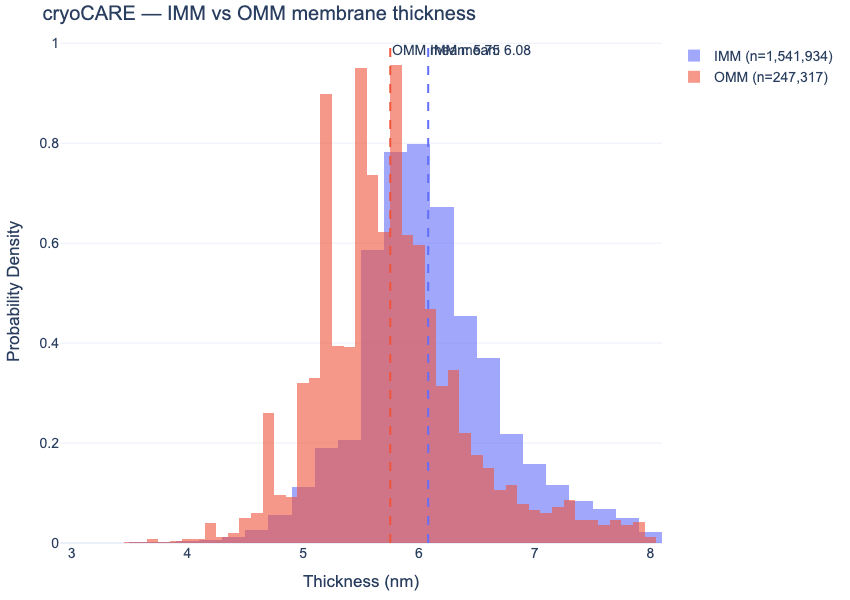

In [8]:
#IFrame(str(plots_path / f"{tomo_names[0]}_IMM_vs_OMM_thickness.html"), width=850, height=600)
Image(str(plots_path / f"{tomo_names[0]}_IMM_vs_OMM_thickness.png"), width=850, height=600)

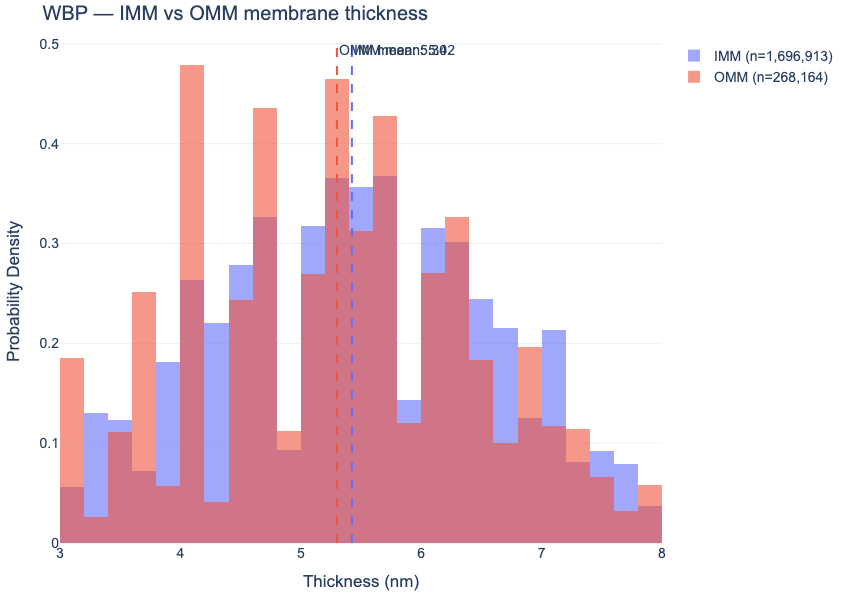

In [9]:
#IFrame(str(plots_path / f"{tomo_names[1]}_IMM_vs_OMM_thickness.html"), width=850, height=600)
Image(str(plots_path / f"{tomo_names[1]}_IMM_vs_OMM_thickness.png"), width=850, height=600)

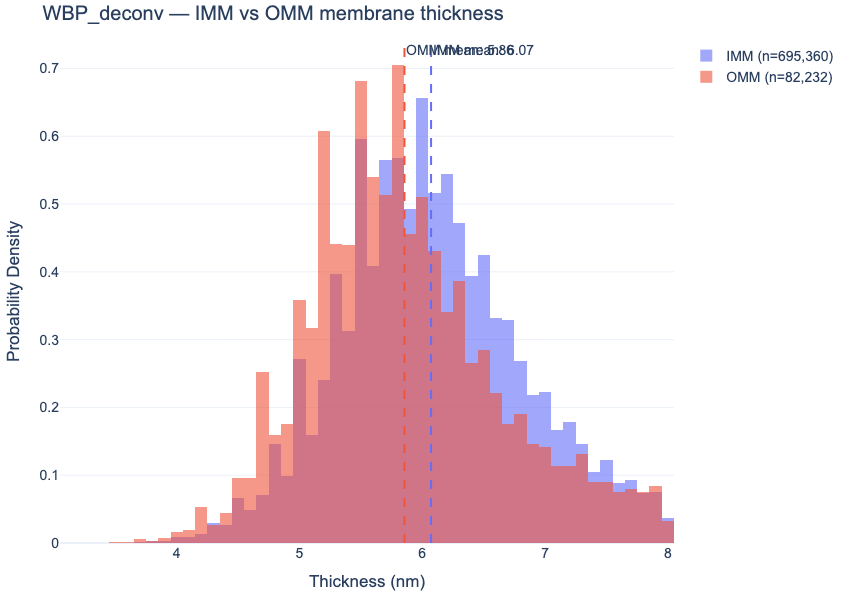

In [10]:
#IFrame(str(plots_path / f"{tomo_names[2]}_IMM_vs_OMM_thickness.html"), width=850, height=600)
Image(str(plots_path / f"{tomo_names[2]}_IMM_vs_OMM_thickness.png"), width=850, height=600)

---

## IMM: comparison across tomograms



In [11]:
# IMM membrane thickness based on inflection points
fig = maple.plot_thickness_distribution(
    [thickness_results[t]["IMM"] for t in tomo_names if "IMM" in thickness_results[t]],
    membrane_names=[t for t in tomo_names if "IMM" in thickness_results[t]],
    thickness_range_nm=thickness_range_nm,
    histogram_bins=50,
    density_normalization=True,
    show_mean_lines=True,
    show_statistics=True,
    opacity=0.6,
    plot_title="IMM — membrane thickness across preprocessing methods",
)
#fig.show()
#fname = plots_path / "IMM_thickness_across_tomos.html"
fname = plots_path / "IMM_thickness_across_tomos.png"
#fig.write_html(str(fname), include_plotlyjs="cdn")
fig.write_image(str(fname), width=850, height=600)


Statistics for cryoCARE:
  Mean:   6.08
  Std:    0.62
  Median: 6.02
  Count:  1,541,934

Statistics for WBP:
  Mean:   5.42
  Std:    1.14
  Median: 5.50
  Count:  1,696,913

Statistics for WBP_deconv:
  Mean:   6.07
  Std:    0.74
  Median: 6.01
  Count:  695,360


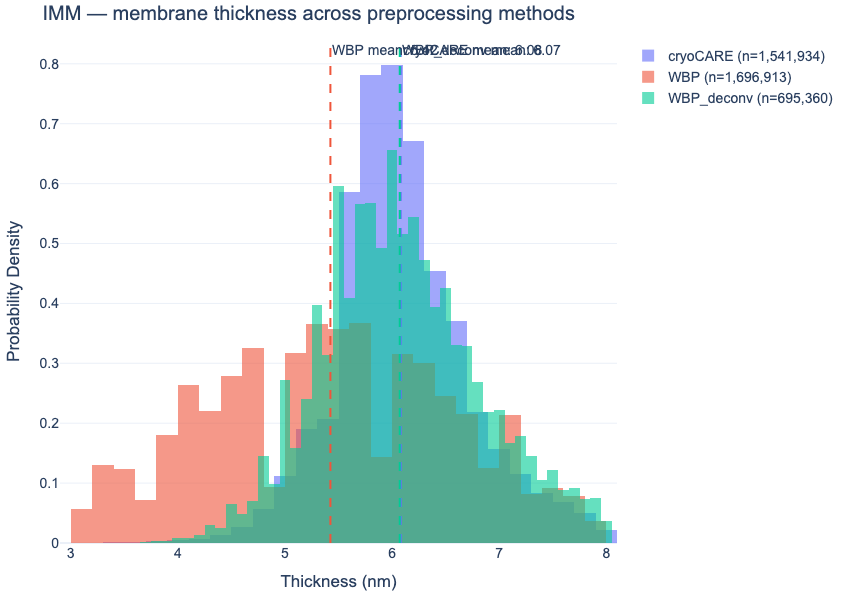

In [12]:
#IFrame(str(fname), width=850, height=600)
Image(str(fname), width=850, height=600)

In [13]:
# IMM min–min distances
first_tomo = next(t for t in tomo_names if "IMM" in profile_results[t])
ps_imm = profile_results[first_tomo]["IMM"].parameters.get("pixel_size_nm")

fig = maple.plot_min_to_min_distribution(
    [thickness_results[t]["IMM"] for t in tomo_names if "IMM" in thickness_results[t]],
    membrane_names=[t for t in tomo_names if "IMM" in thickness_results[t]],
    minima_separation_range_nm=(2.0, 6.0),
    histogram_bins=30,
    density_normalization=True,
    show_mean_lines=True,
    show_statistics=True,
    opacity=0.6,
    pixel_size_nm=ps_imm,
    plot_title="IMM — min–min distance across preprocessing methods",
)
#fig.show()
#fname = plots_path / "IMM_min_min_across_tomos.html"
fname = plots_path / "IMM_min_min_across_tomos.png"
#fig.write_html(str(fname), include_plotlyjs="cdn")
fig.write_image(str(fname), width=850, height=600)


Statistics for cryoCARE:
  Mean:   3.99
  Std:    0.57
  Median: 4.00
  Count:  1,747,964

Statistics for WBP:
  Mean:   3.58
  Std:    0.88
  Median: 3.50
  Count:  1,713,123

Statistics for WBP_deconv:
  Mean:   3.82
  Std:    0.72
  Median: 3.83
  Count:  1,233,150


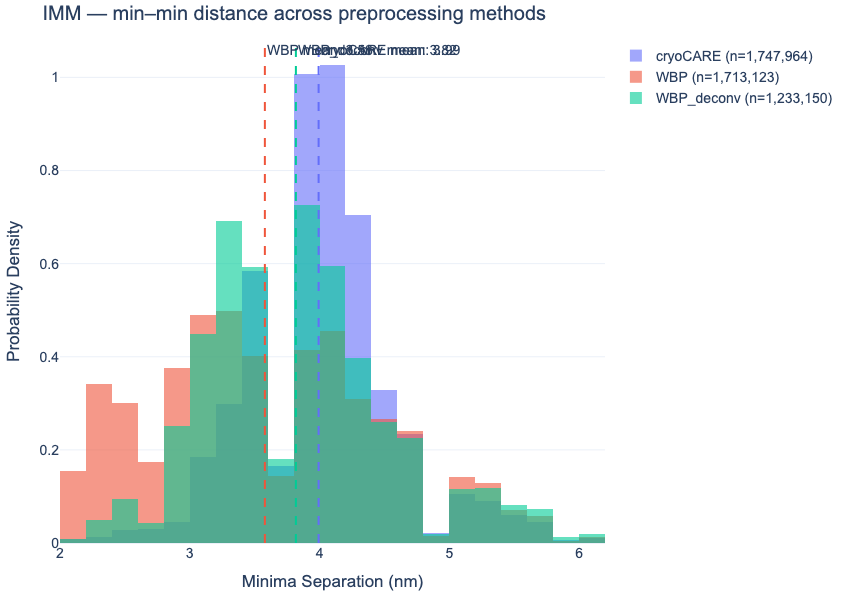

In [14]:
#IFrame(str(fname), width=850, height=600)
Image(str(fname), width=850, height=600)

---

## OMM: comparison across tomograms



In [15]:
# OMM membrane thickness based on inflection points
fig = maple.plot_thickness_distribution(
    [thickness_results[t]["OMM"] for t in tomo_names if "OMM" in thickness_results[t]],
    membrane_names=[t for t in tomo_names if "OMM" in thickness_results[t]],
    thickness_range_nm=thickness_range_nm,
    histogram_bins=50,
    density_normalization=True,
    show_mean_lines=True,
    show_statistics=True,
    opacity=0.6,
    plot_title="OMM — membrane thickness across preprocessing methods",
)
#fig.show()
fname = plots_path / "OMM_thickness_across_tomos.png"
#fig.write_html(str(fname), include_plotlyjs="cdn")
fig.write_image(str(fname), width=850, height=600)


Statistics for cryoCARE:
  Mean:   5.75
  Std:    0.64
  Median: 5.70
  Count:  247,317

Statistics for WBP:
  Mean:   5.30
  Std:    1.14
  Median: 5.24
  Count:  268,164

Statistics for WBP_deconv:
  Mean:   5.86
  Std:    0.78
  Median: 5.76
  Count:  82,232


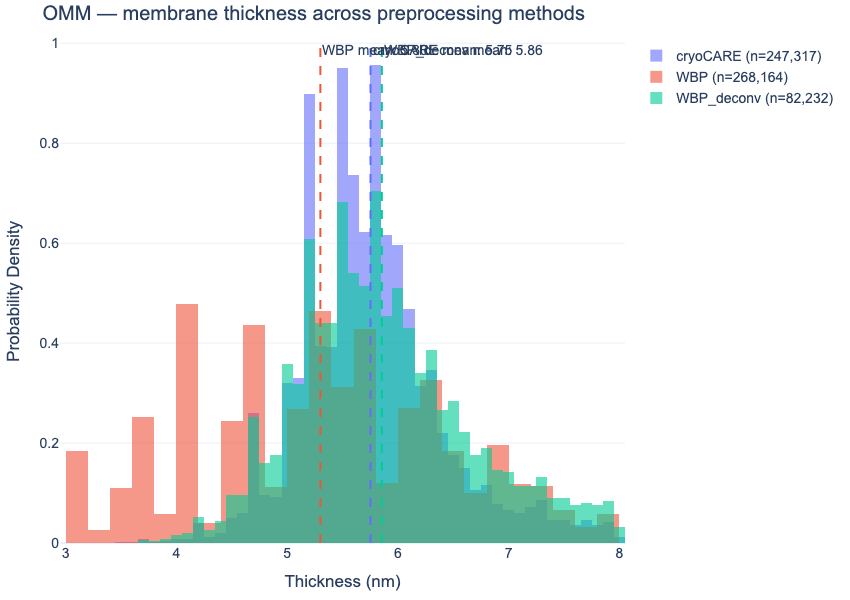

In [16]:
#IFrame(str(fname), width=850, height=600)
Image(str(fname), width=850, height=600)

In [17]:
# OMM min–min distances
first_tomo_omm = next(t for t in tomo_names if "OMM" in profile_results[t])
ps_omm = profile_results[first_tomo_omm]["OMM"].parameters.get("pixel_size_nm")

fig = maple.plot_min_to_min_distribution(
    [thickness_results[t]["OMM"] for t in tomo_names if "OMM" in thickness_results[t]],
    membrane_names=[t for t in tomo_names if "OMM" in thickness_results[t]],
    minima_separation_range_nm=(2.0, 6.0),
    histogram_bins=30,
    density_normalization=True,
    show_mean_lines=True,
    show_statistics=True,
    opacity=0.6,
    pixel_size_nm=ps_omm,
    plot_title="OMM — min–min distance across preprocessing methods",
)
#fig.show()
fname = plots_path / "OMM_min_min_across_tomos.png"
#fig.write_html(str(fname), include_plotlyjs="cdn")
fig.write_image(str(fname), width=850, height=600)


Statistics for cryoCARE:
  Mean:   3.66
  Std:    0.62
  Median: 3.67
  Count:  265,084

Statistics for WBP:
  Mean:   3.40
  Std:    0.90
  Median: 3.14
  Count:  274,372

Statistics for WBP_deconv:
  Mean:   3.60
  Std:    0.80
  Median: 3.50
  Count:  138,867


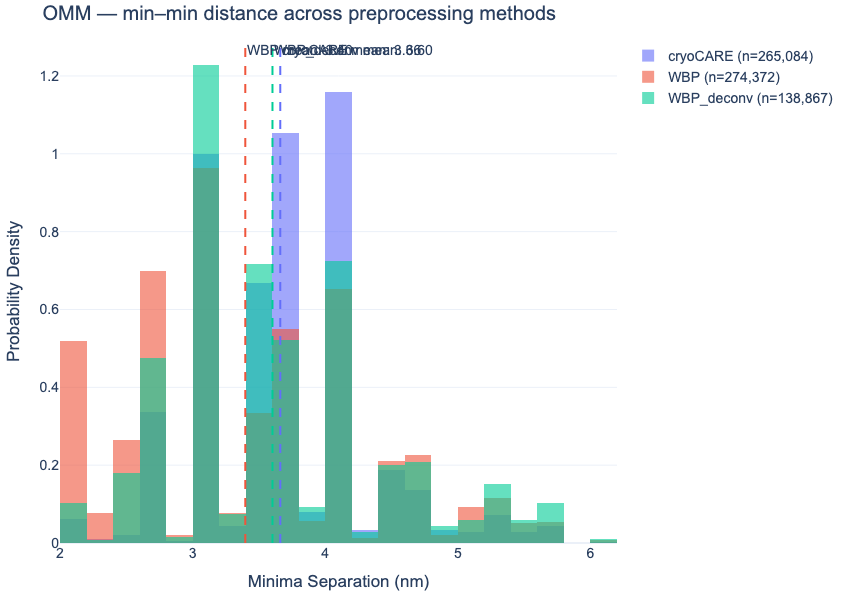

In [18]:
#IFrame(str(fname), width=850, height=600)
Image(str(fname), width=850, height=600)

---

## Intensity profile summaries

`plot_intensity_profile_summary` stacks all stored profiles, interpolates them onto a common distance axis, and shows the mean intensity with a 25th–75th percentile band.

**Vertical markers:**
- **Gray dashed** — mean positions of the geometrically matched segmentation surface points (mean `match_distance_nm`).
- **Green / red dashed** — mean left and right **inflection points** (mean `membrane_thickness_nm`).
- **Dark grey solid** — mean geometric midpoint between the two minima.


In [19]:
for membrane in membrane_names:
    for tomo in tomo_names:
        if membrane not in membrane_data[tomo]:
            continue
        fig = maple.plot_intensity_profile_summary(
            membrane_data[tomo][membrane],
            membrane_names=[f"{membrane} ({tomo})"],
            show_segmentation_boundary_markers=True,
            show_segmentation_boundary_distributions=True,
            show_inflection_point_markers=True,
            show_inflection_point_distributions=True,
            show_minima_midpoint=True,
            plot_title=f"{membrane} — mean intensity profiles ({tomo})",
        )
        #fig.show()
        #fname = plots_path / f"{membrane}_{tomo}_profiles_all.html"
        fname = plots_path / f"{membrane}_{tomo}_profiles_all.png"
        #fig.write_html(str(fname), include_plotlyjs="cdn")
        fig.write_image(str(fname), width=850, height=600)

IMM all profiles— cryoCARE


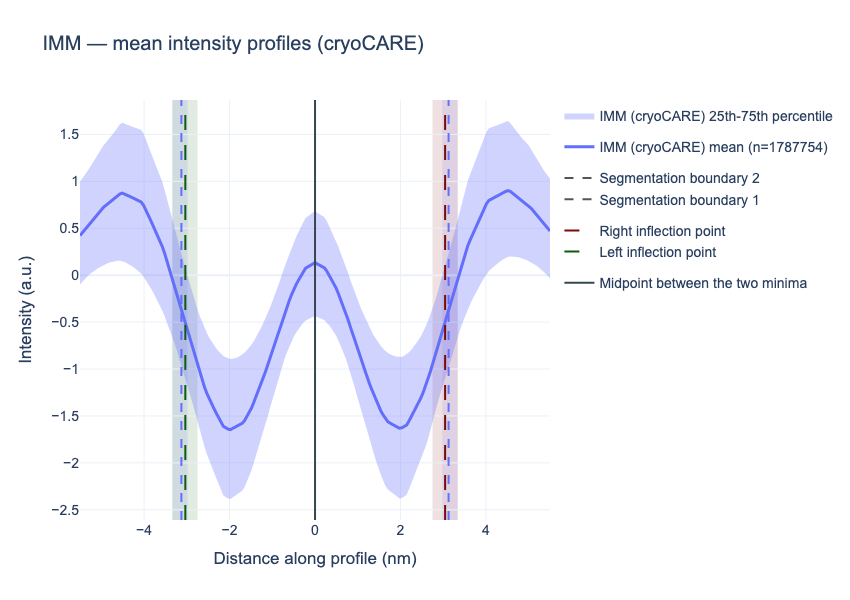

IMM all profiles— WBP


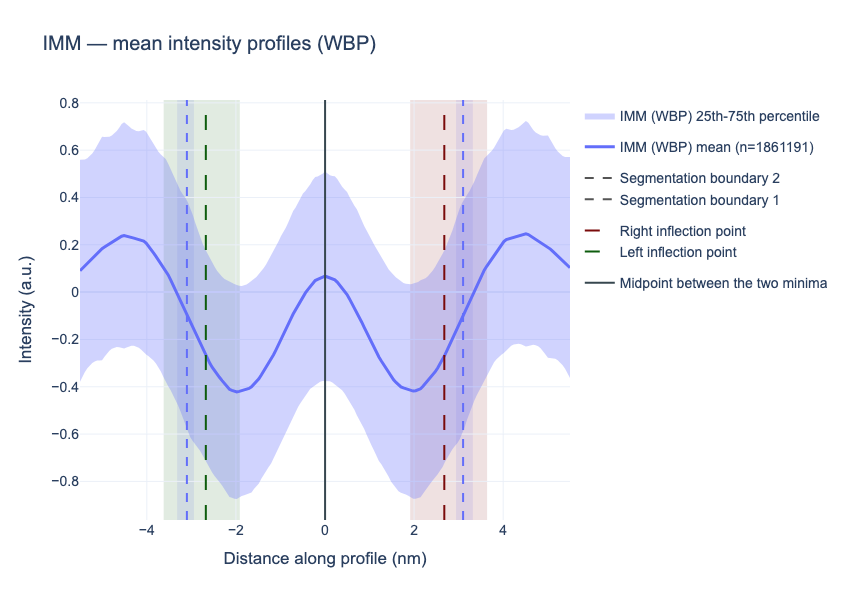

IMM all profiles— WBP_deconv


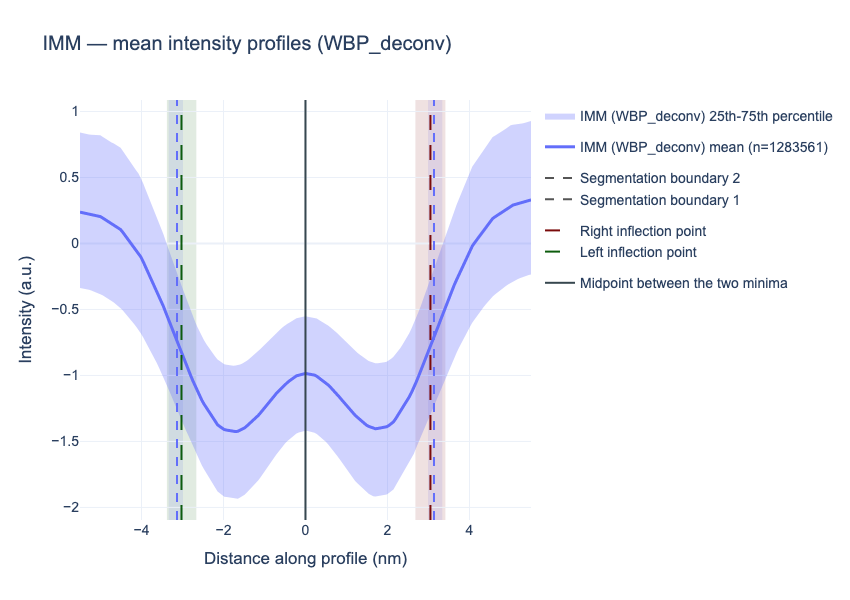

In [20]:
# IMM
for tomo in tomo_names:
    print(f"IMM all profiles— {tomo}")
    #display(IFrame(str(plots_path / f"IMM_{tomo}_profiles_all.html"), width=850, height=550))
    display(Image(str(plots_path / f"IMM_{tomo}_profiles_all.png"), width=850, height=550))

OMM all profiles— cryoCARE


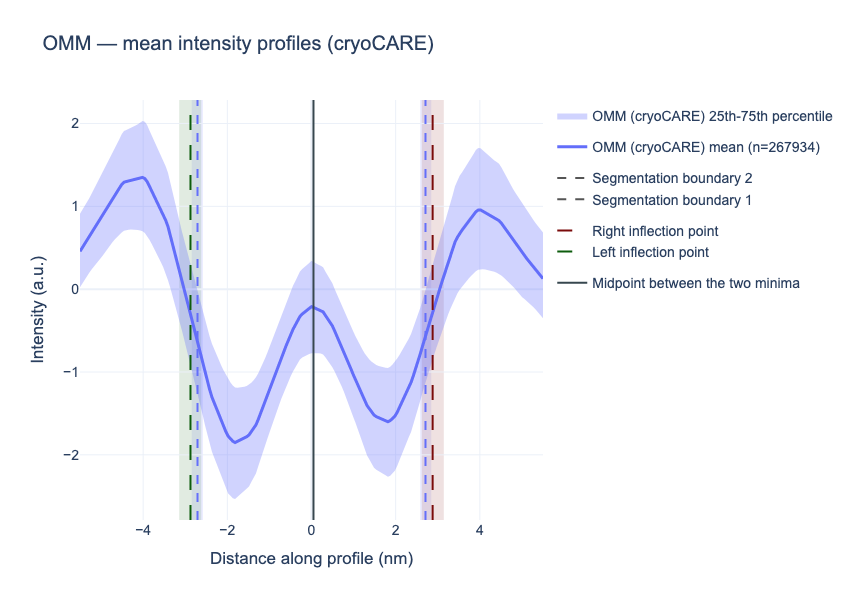

OMM all profiles— WBP


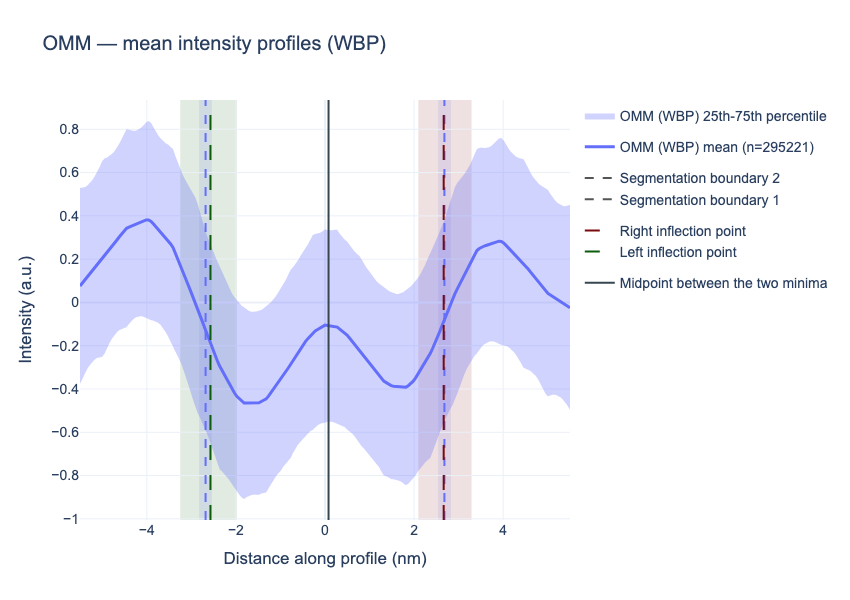

OMM all profiles— WBP_deconv


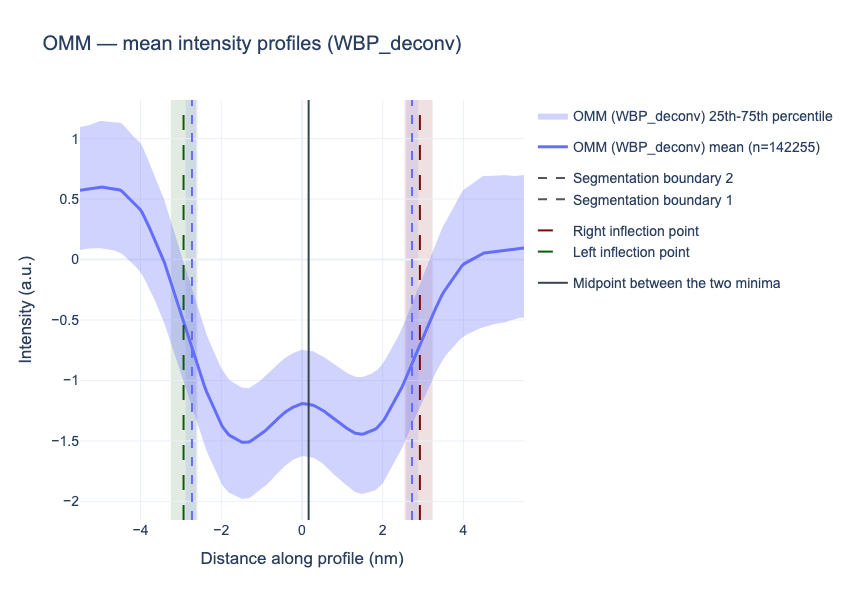

In [21]:
# OMM
for tomo in tomo_names:
    print(f"OMM all profiles— {tomo}")
    #display(IFrame(str(plots_path / f"OMM_{tomo}_profiles_all.html"), width=850, height=550))
    display(Image(str(plots_path / f"OMM_{tomo}_profiles_all.png"), width=850, height=550))

---

## Profiles: two outward maxima

Filtering to `thickness_regime="max_max"` keeps only profiles where both outward maxima were detected as genuine peaks. Both inflection-point boundaries are independently determined, making this the highest-confidence subset.



In [22]:
for membrane in membrane_names:
    for tomo in tomo_names:
        if membrane not in membrane_data[tomo]:
            continue
        try:
            fig = maple.plot_intensity_profile_summary(
                membrane_data[tomo][membrane],
                membrane_names=[f"{membrane} ({tomo})"],
                thickness_regime="max_max",
                show_segmentation_boundary_markers=True,
                show_segmentation_boundary_distributions=True,
                show_inflection_point_markers=True,
                show_inflection_point_distributions=True,
                show_minima_midpoint=True,
                plot_title=f"{membrane} — two outward maxima profiles ({tomo})",
            )
            #fname = plots_path / f"{membrane}_{tomo}_profiles_max_max.html"
            fname = plots_path / f"{membrane}_{tomo}_profiles_max_max.png"
            #fig.write_html(str(fname), include_plotlyjs="cdn")
            fig.write_image(str(fname), width=850, height=600)
            #fig.show()
        except ValueError as e:
            print(f"  {tomo}: skipped — {e}")

IMM two outward maxima profiles— cryoCARE


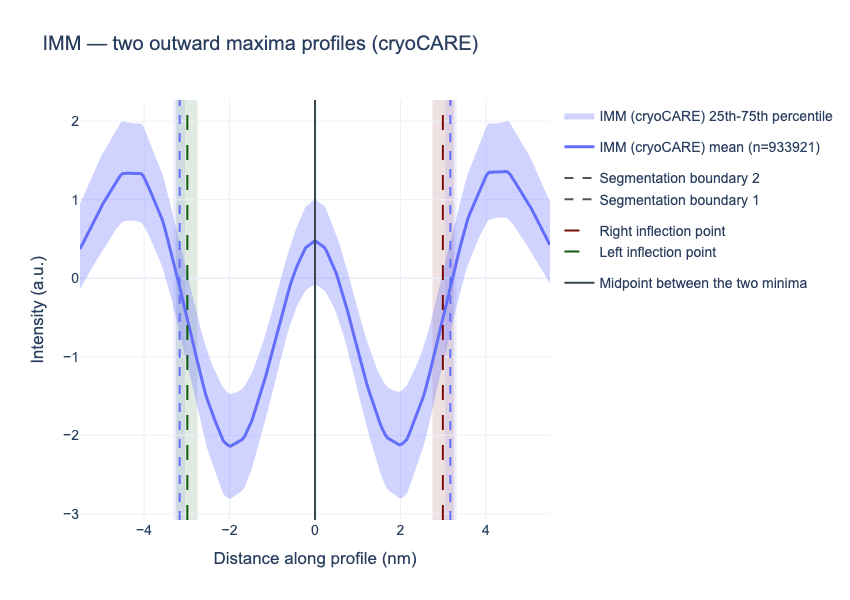

IMM two outward maxima profiles— WBP


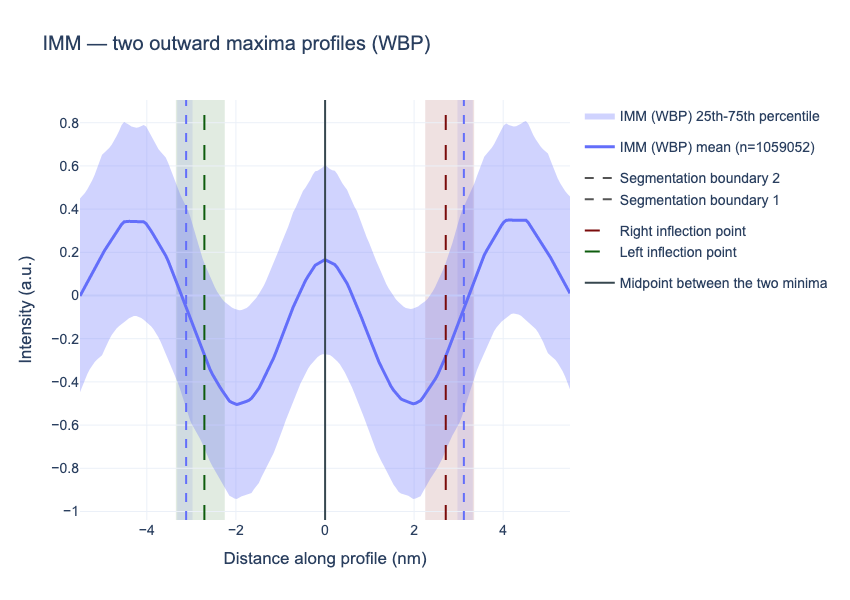

IMM two outward maxima profiles— WBP_deconv


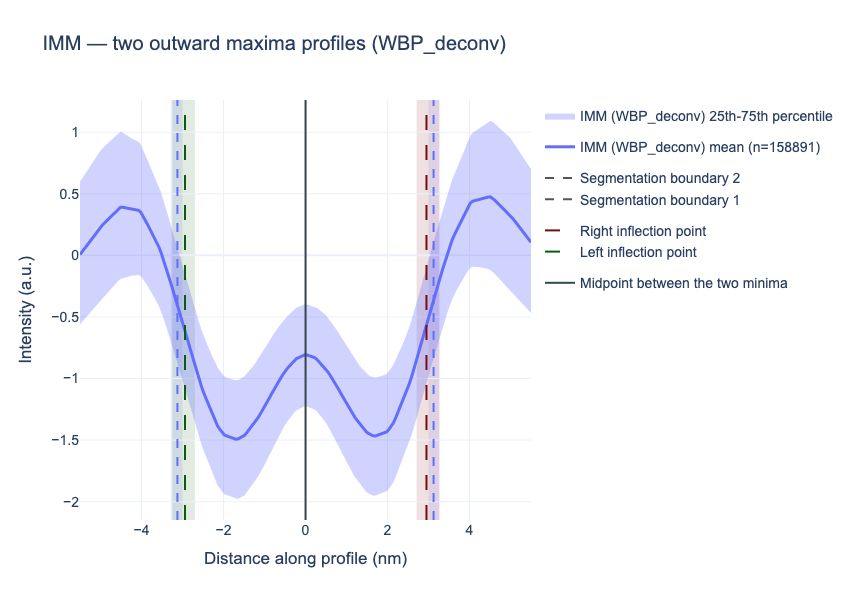

In [24]:
# IMM
for tomo in tomo_names:
    fname = plots_path / f"IMM_{tomo}_profiles_max_max.png"
    if fname.exists():
        print(f"IMM two outward maxima profiles— {tomo}")
        display(Image(str(fname), width=850, height=550))

OMM two outward maxima profiles— cryoCARE


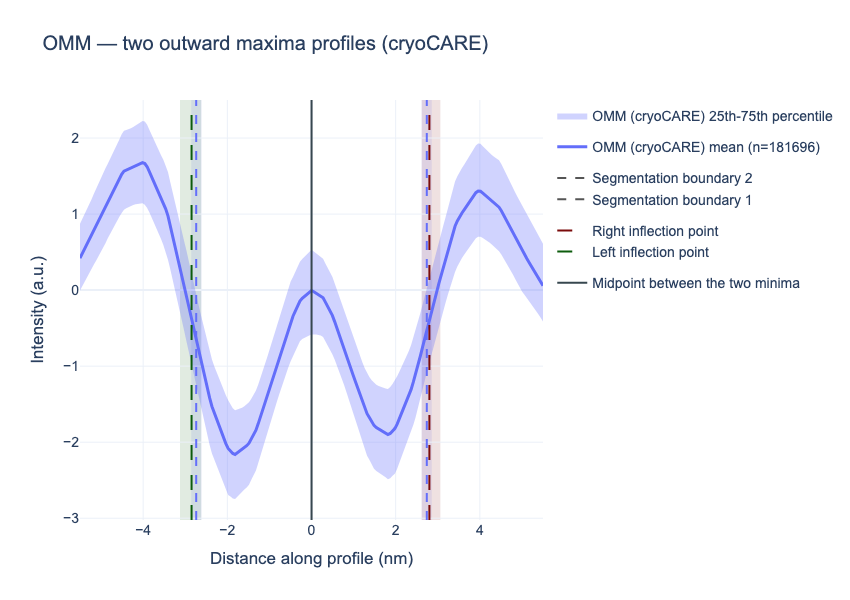

OMM two outward maxima profiles— WBP


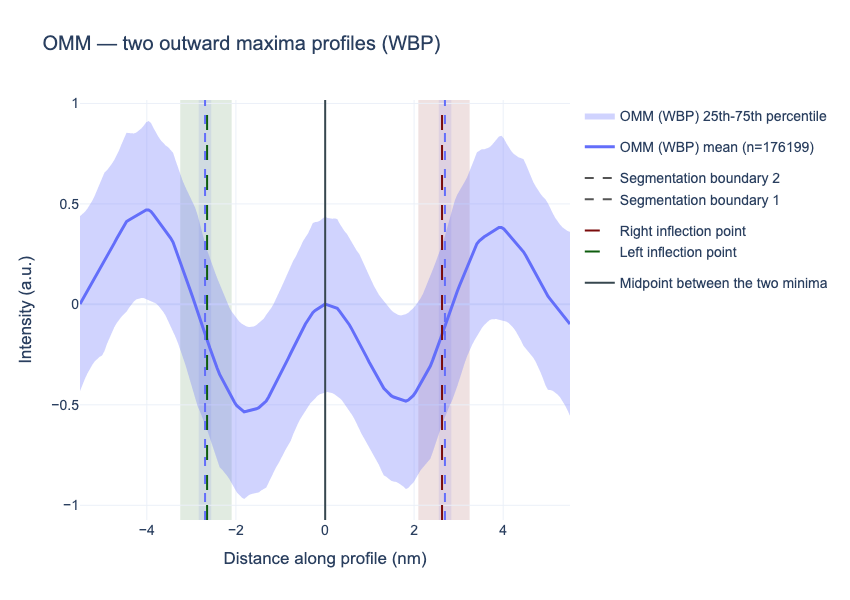

OMM two outward maxima profiles— WBP_deconv


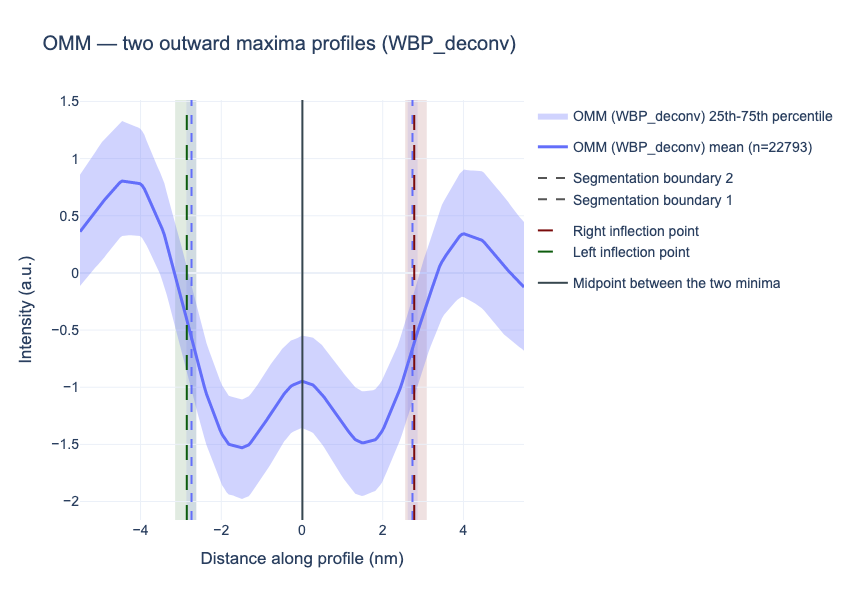

In [25]:
# OMM
for tomo in tomo_names:
    fname = plots_path / f"OMM_{tomo}_profiles_max_max.png"
    if fname.exists():
        print(f"OMM two outward maxima profiles— {tomo}")
        display(Image(str(fname), width=850, height=550))

---

## Profiles: mirrored maximum

Filtering to `thickness_regime="max_anchor"` keeps profiles where one boundary was found from a real outward maximum and the other was inferred by mirroring the good side's max-to-min span. See the `IntensityProfileAnalyzer` documentation in [`memthick_run.ipynb`](memthick_run.ipynb) for details on how the mirroring works.



In [26]:
for membrane in membrane_names:
    for tomo in tomo_names:
        if membrane not in membrane_data[tomo]:
            continue
        try:
            fig = maple.plot_intensity_profile_summary(
                membrane_data[tomo][membrane],
                membrane_names=[f"{membrane} ({tomo})"],
                thickness_regime="max_anchor",
                show_segmentation_boundary_markers=True,
                show_segmentation_boundary_distributions=True,
                show_inflection_point_markers=True,
                show_inflection_point_distributions=True,
                show_minima_midpoint=True,
                plot_title=f"{membrane} — mirrored max profiles ({tomo})",
            )
            #fname = plots_path / f"{membrane}_{tomo}_profiles_max_anchor.html"
            fname = plots_path / f"{membrane}_{tomo}_profiles_max_anchor.png"
            #fig.write_html(str(fname), include_plotlyjs="cdn")
            fig.write_image(str(fname), width=850, height=600)
            #fig.show()
        except ValueError as e:
            print(f"  {tomo}: skipped — {e}")

IMM mirrored max profiles— cryoCARE


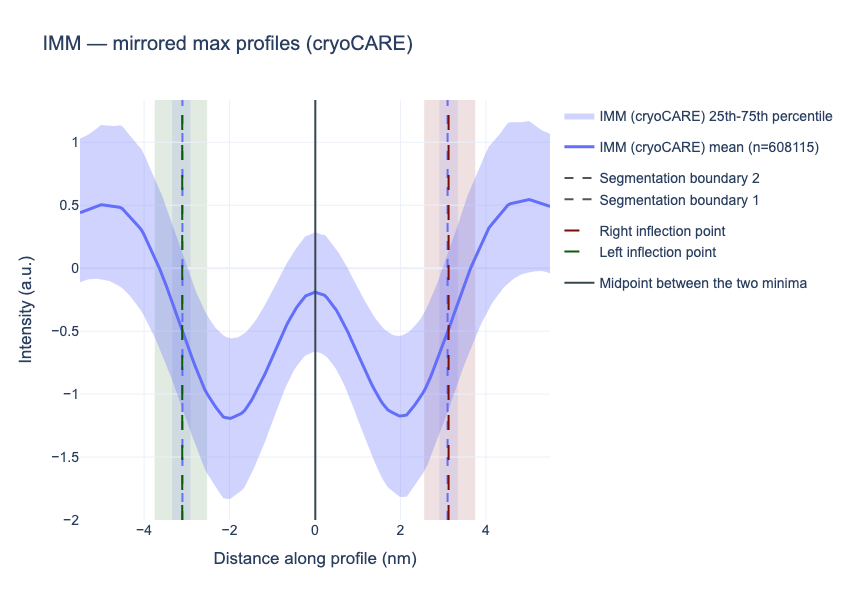

IMM mirrored max profiles— WBP


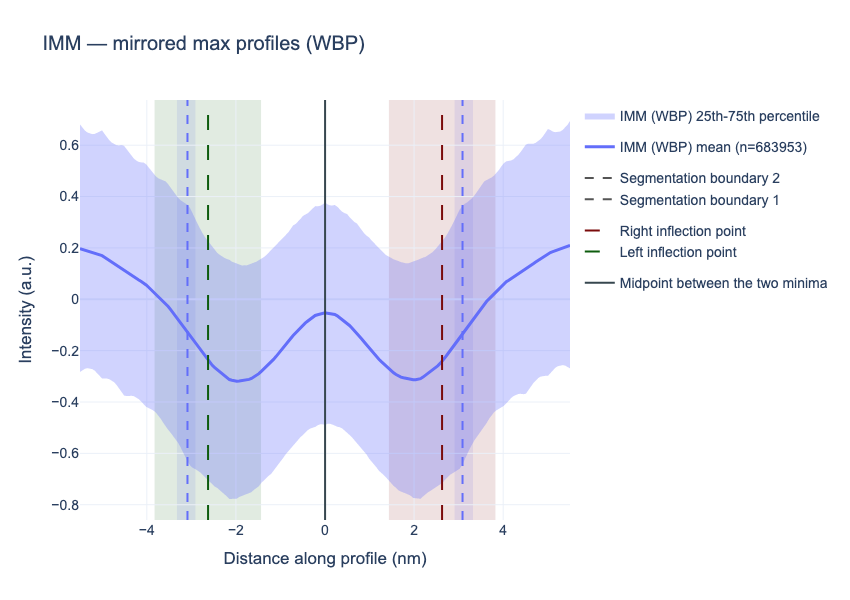

IMM mirrored max profiles— WBP_deconv


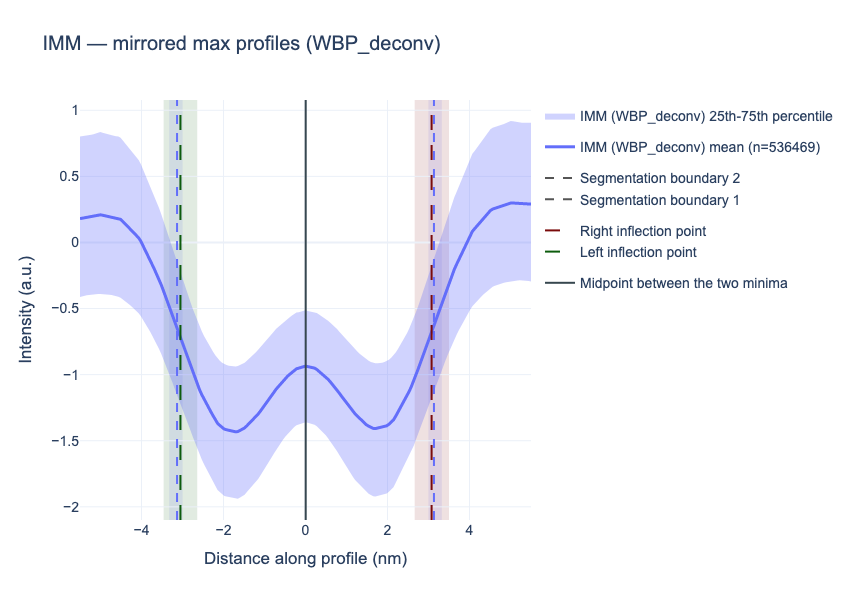

In [27]:
# IMM
for tomo in tomo_names:
    fname = plots_path / f"IMM_{tomo}_profiles_max_anchor.png"
    if fname.exists():
        print(f"IMM mirrored max profiles— {tomo}")
        display(Image(str(fname), width=850, height=550))

OMM mirrored max profiles— cryoCARE


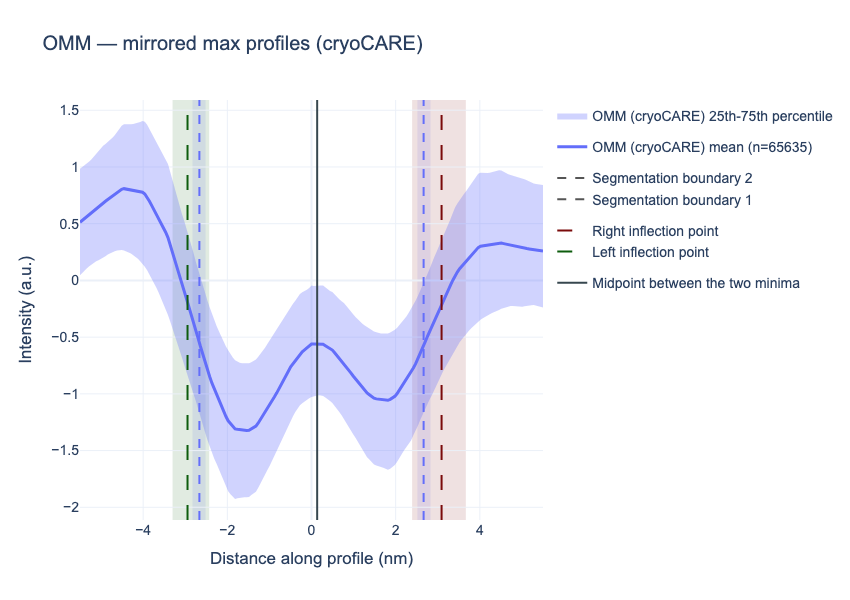

OMM mirrored max profiles— WBP


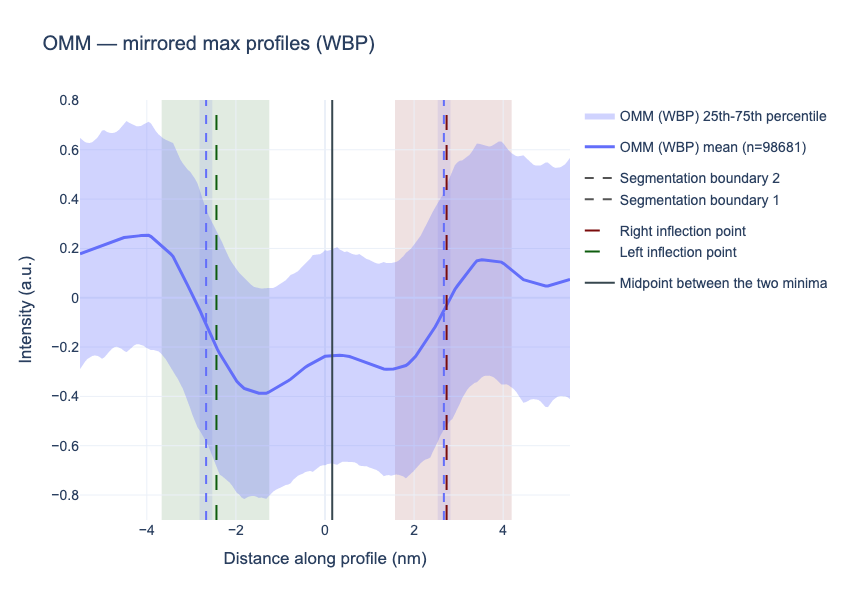

OMM mirrored max profiles— WBP_deconv


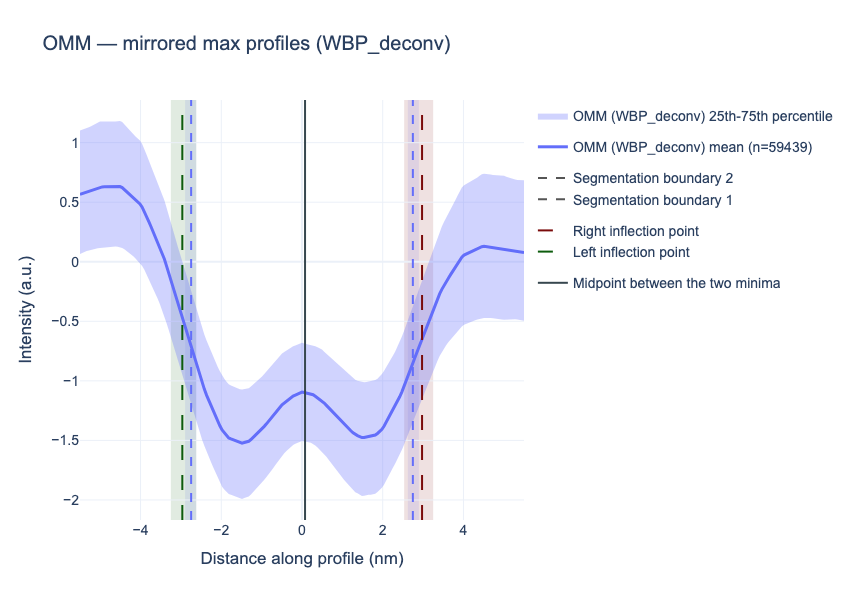

In [28]:
# OMM
for tomo in tomo_names:
    fname = plots_path / f"OMM_{tomo}_profiles_max_anchor.png"
    if fname.exists():
        print(f"OMM mirrored max profiles— {tomo}")
        display(Image(str(fname), width=850, height=550))